In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
X,y=make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    random_state=42
)
y=y.reshape(-1,1)
# print(X.shape)
# print(X)
# print(y.shape)
# print(y)

In [2]:
class LogisticRegressionGD:
    def __init__(self,lr=0.1,epochs=15):
        self.lr=lr
        self.epochs=epochs
    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
    def compute_loss(self,y,y_hat):
        eps=1e-8
        return -np.sum(
            y*np.log(y_hat+eps)+
            (1-y)*np.log(1-y_hat+eps)
        )
    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.w=np.random.randn(n_features,1)*0.01
        self.b=0
        self.loss_history=[]
        for epoch in range(self.epochs):
            z=X@self.w+self.b
            y_hat=self.sigmoid(z)
            loss=self.compute_loss(y,y_hat)
            self.loss_history.append(loss)
            dw=(1/n_samples)*X.T@(y_hat-y)
            db=np.mean(y_hat-y)
            self.w-=self.lr*dw
            self.b-=self.lr*db
            print(f"epoch{epoch:2d}|loss={loss:.4f}")

epoch 0|loss=344.7599
epoch 1|loss=331.1016
epoch 2|loss=318.7607
epoch 3|loss=307.5982
epoch 4|loss=297.4859
epoch 5|loss=288.3075
epoch 6|loss=279.9584
epoch 7|loss=272.3458
epoch 8|loss=265.3875
epoch 9|loss=259.0114
epoch10|loss=253.1540
epoch11|loss=247.7599
epoch12|loss=242.7802
epoch13|loss=238.1722
epoch14|loss=233.8985


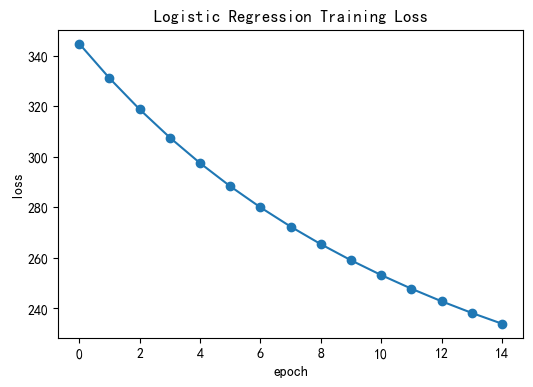

In [4]:
model=LogisticRegressionGD(lr=0.1,epochs=15)
model.fit(X,y)
plt.figure(figsize=(6,4))
plt.plot(model.loss_history,marker='o')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Logistic Regression Training Loss")
plt.show()